In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

BASE_PATH = '/content/drive/Shareddrives/Sieci_Neuronowe/Projekt_1'

with open(f'{BASE_PATH}/long_training_vit_best_150ep.json', 'r', encoding='utf-8') as f:
    long_data = json.load(f)

with open(f'{BASE_PATH}/porownanie_wynikow.json', 'r', encoding='utf-8') as f:
    main_data = json.load(f)

long = long_data['cifar10']

# Wyciągnij ViT_Best 10 epok do porównania
vit_best_10 = next(x for x in main_data['cifar10'] if x['experiment'] == 'ViT_Best')
cnn_10      = next(x for x in main_data['cifar10'] if x['experiment'] == 'epoki' and x['param_value'] == 10)

print('Dane załadowane pomyślnie!')
print(f'ViT_Best 150 ep  — best test acc: {long["best_test_acc"]:.2f}% @ epoch {long["best_epoch"]}')
print(f'ViT_Best  10 ep  — test acc:      {vit_best_10["test_acc"]:.2f}%')
print(f'CNN       10 ep  — test acc:      {cnn_10["test_acc"]:.2f}%')

Mounted at /content/drive
Dane załadowane pomyślnie!
ViT_Best 150 ep  — best test acc: 81.17% @ epoch 130
ViT_Best  10 ep  — test acc:      72.73%
CNN       10 ep  — test acc:      72.04%


## 1. Krzywa Treningu — Accuracy

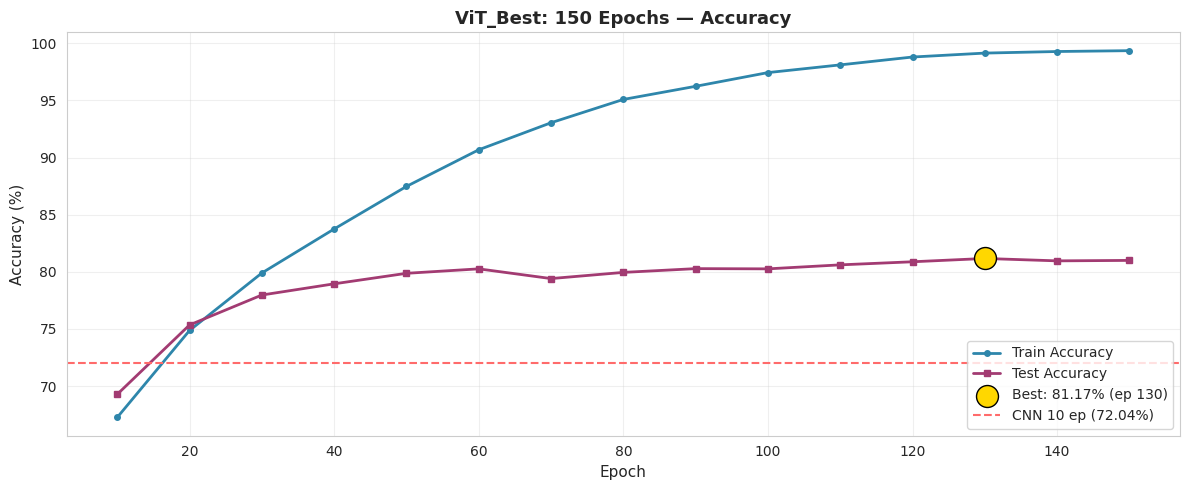

In [2]:
h = long['history']
epochs    = [x['epoch']     for x in h]
train_acc = [x['train_acc'] for x in h]
test_acc  = [x['test_acc']  for x in h]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epochs, train_acc, 'o-', label='Train Accuracy', color='#2E86AB', lw=2, markersize=4)
ax.plot(epochs, test_acc,  's-', label='Test Accuracy',  color='#A23B72', lw=2, markersize=4)

# Zaznacz najlepszy wynik
best_idx = int(np.argmax(test_acc))
ax.scatter([epochs[best_idx]], [test_acc[best_idx]],
           s=250, color='gold', edgecolor='black', zorder=5,
           label=f'Best: {test_acc[best_idx]:.2f}% (ep {epochs[best_idx]})')

# Linia referencyjna: CNN 10 ep
ax.axhline(cnn_10['test_acc'], color='#FF6B6B', linestyle='--', lw=1.5,
           label=f'CNN 10 ep ({cnn_10["test_acc"]:.2f}%)')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('ViT_Best: 150 Epochs — Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/bonus_01_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Krzywa Treningu — Loss

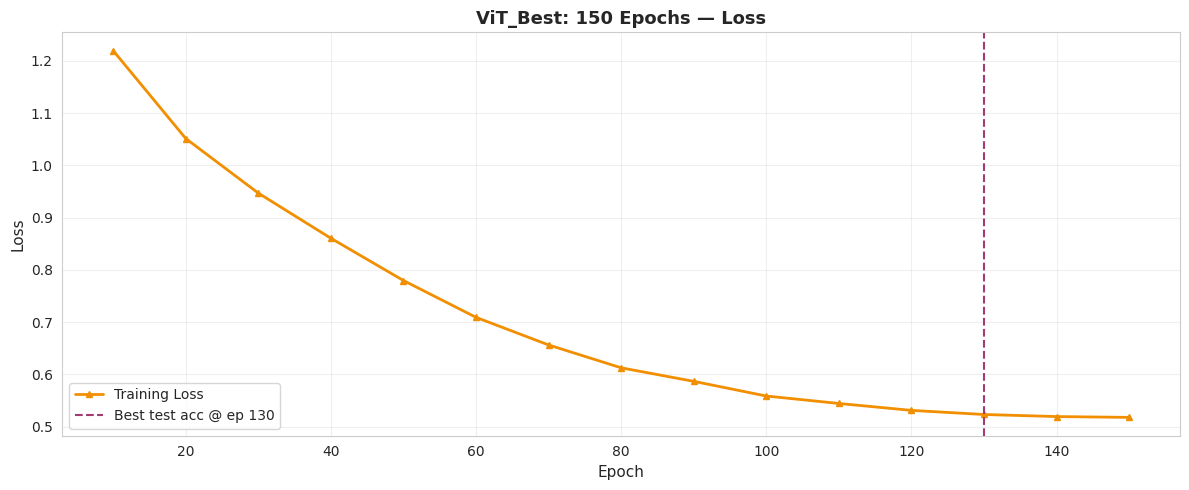

In [3]:
loss = [x['loss'] for x in h]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epochs, loss, '^-', color='#F18F01', lw=2, markersize=4, label='Training Loss')

# Zaznacz epoch z najlepszym test acc
ax.axvline(epochs[best_idx], color='#A23B72', linestyle='--', lw=1.5,
           label=f'Best test acc @ ep {epochs[best_idx]}')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('ViT_Best: 150 Epochs — Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/bonus_02_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Porównanie: CNN vs ViT (10 ep) vs ViT (150 ep)

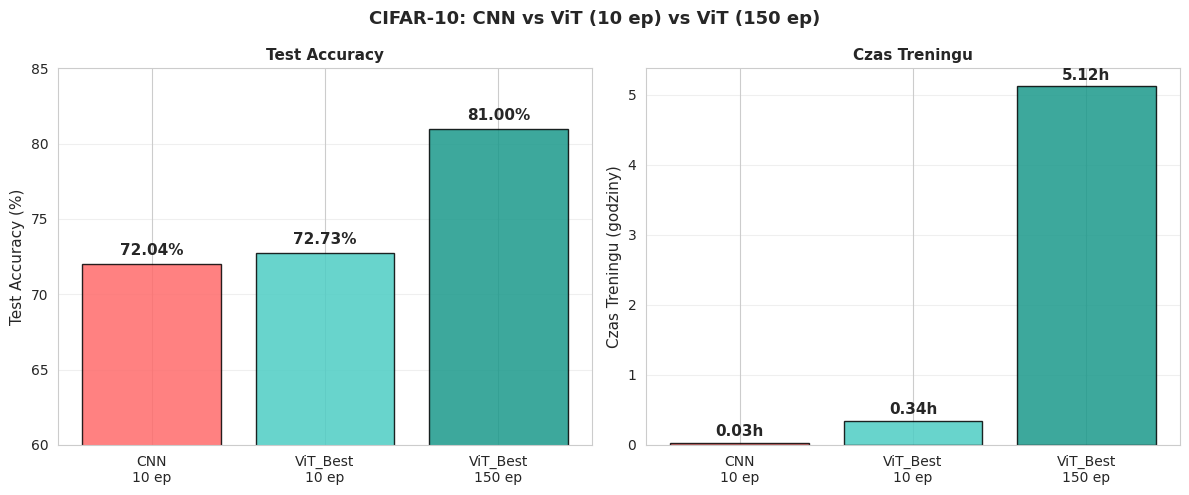

In [4]:
models  = ['CNN\n10 ep', 'ViT_Best\n10 ep', 'ViT_Best\n150 ep']
accs    = [cnn_10['test_acc'], vit_best_10['test_acc'], long['test_acc']]
times_h = [cnn_10['train_time_s']/3600, vit_best_10['train_time_s']/3600, long['train_time_s']/3600]
colors  = ['#FF6B6B', '#4ECDC4', '#1B998B']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CIFAR-10: CNN vs ViT (10 ep) vs ViT (150 ep)', fontsize=13, fontweight='bold')

# Accuracy
bars = axes[0].bar(models, accs, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0].set_title('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_ylim(60, 85)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.4, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Czas
axes[1].bar(models, times_h, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Czas Treningu (godziny)', fontsize=11)
axes[1].set_title('Czas Treningu', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(times_h):
    axes[1].text(i, v + 0.05, f'{v:.2f}h', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/bonus_03_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Milestones — postęp co 10 epok

In [5]:
# Dane co 10 epok (lub tyle ile dostępne)
milestones = [x for x in h if x['epoch'] % 10 == 0]
ep_m    = [x['epoch']     for x in milestones]
tacc_m  = [x['train_acc'] for x in milestones]
teacc_m = [x['test_acc']  for x in milestones]
loss_m  = [x['loss']      for x in milestones]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT_Best 150 ep — Milestones co 10 epok', fontsize=13, fontweight='bold')

x = np.arange(len(ep_m))
w = 0.4

# Accuracy (grouped bar)
axes[0].bar(x - w/2, tacc_m,  w, label='Train Acc', color='#2E86AB', alpha=0.85, edgecolor='black')
axes[0].bar(x + w/2, teacc_m, w, label='Test Acc',  color='#A23B72', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'ep {e}' for e in ep_m], rotation=45)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Loss
axes[1].bar(x, loss_m, color='#F18F01', alpha=0.85, edgecolor='black', label='Loss')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'ep {e}' for e in ep_m], rotation=45)
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/bonus_04_milestones.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'h' is not defined

## 5. Podsumowanie

In [3]:
print('='*60)
print('PODSUMOWANIE — BONUS 150 EPOK')
print('='*60)
print(f'\nViT_Best 150 ep:')
print(f'  Best Test Accuracy : {long["best_test_acc"]:.2f}%  @ epoch {long["best_epoch"]}')
print(f'  Final Test Accuracy: {long["test_acc"]:.2f}%')
print(f'  Train Accuracy     : {long["train_acc"]:.2f}%')
print(f'  Overfitting gap    : {long["train_acc"] - long["test_acc"]:.2f}%')
print(f'  Czas treningu      : {long["train_time_s"]/3600:.2f}h  ({long["train_time_s"]:.0f}s)')
print(f'  Parametry          : {long["num_params"]/1e6:.2f}M')
print()
print(f'Porównanie (CIFAR-10):')
print(f'  CNN 10 ep          : {cnn_10["test_acc"]:.2f}%   ({cnn_10["train_time_s"]:.0f}s)')
print(f'  ViT_Best 10 ep     : {vit_best_10["test_acc"]:.2f}%  ({vit_best_10["train_time_s"]:.0f}s)')
print(f'  ViT_Best 150 ep    : {long["test_acc"]:.2f}%  ({long["train_time_s"]:.0f}s)')
print('='*60)

PODSUMOWANIE — BONUS 150 EPOK

ViT_Best 150 ep:


NameError: name 'long' is not defined